In [ ]:
from virtual_accelerator.models.cu_hxr import get_cu_inj_impact_model

model = get_cu_inj_impact_model(n_particles=1000)

In [2]:
model.supported_variables

{'distgen:n_particle': DistgenInputAction(name='distgen:n_particle', description='', read_only=False, default_validation_config='none', default_value=None, value_range=None, unit=None, key='n_particle'),
 'distgen:total_charge': DistgenInputAction(name='distgen:total_charge', description='', read_only=False, default_validation_config='none', default_value=None, value_range=None, unit='picocoulomb', key='total_charge:value'),
 'distgen:start:cathode:MTE': DistgenInputAction(name='distgen:start:cathode:MTE', description='', read_only=False, default_validation_config='none', default_value=None, value_range=None, unit='millielectron_volt', key='start:MTE:value'),
 'distgen:r_dist:sigma_xy': DistgenInputAction(name='distgen:r_dist:sigma_xy', description='', read_only=False, default_validation_config='none', default_value=None, value_range=None, unit='millimeter', key='r_dist:sigma_xy:value'),
 'distgen:t_dist:length': DistgenInputAction(name='distgen:t_dist:length', description='', read_onl

In [3]:
print("model default BACT:", model.get(["SOLN:IN20:121:BACT"])["SOLN:IN20:121:BACT"])
print("IMPACT value:", model.impact_model.simulator.ele["SOL1"]["solenoid_field_scale"])
print("Setting a new value")
model.set({"SOLN:IN20:121:BCTRL": 0.45})
print("Reading it back:", model.get(["SOLN:IN20:121:BACT"])["SOLN:IN20:121:BACT"])
print("Closing the loop with IMPACT:", model.impact_model.simulator.ele["SOL1"]["solenoid_field_scale"])

model default BACT: 0.4005568844636836
IMPACT value: 0.2457
Setting a new value
Reading it back: 0.45000000000000007
Closing the loop with IMPACT: 0.2760282104451618


In [4]:
print(model.get(["group:L0B_scale"]))
print(model.get(["ACCL:IN20:400:L0B_ADES"]))

{'group:L0B_scale': 70000000.0}
{'ACCL:IN20:400:L0B_ADES': 70.0}


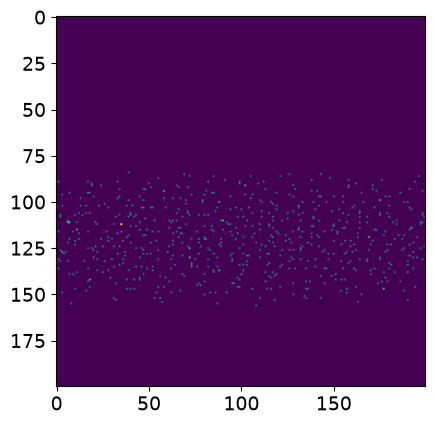

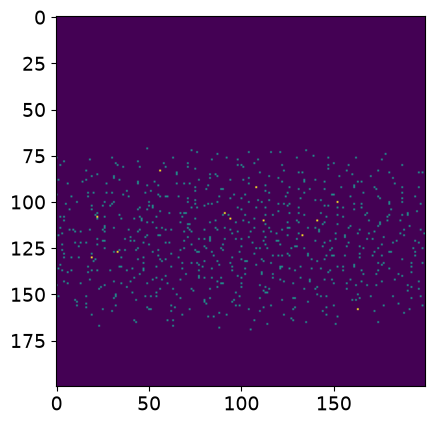

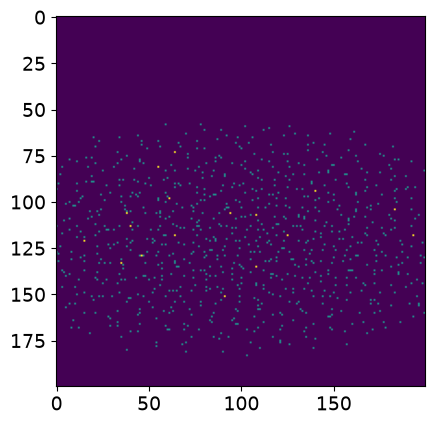

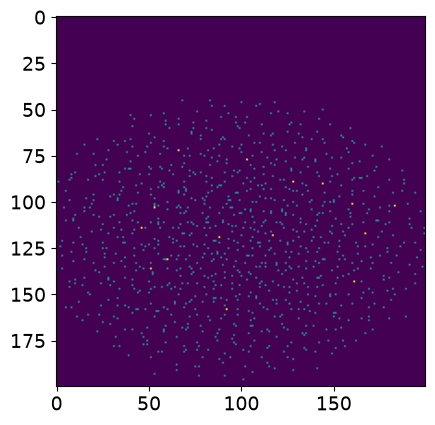

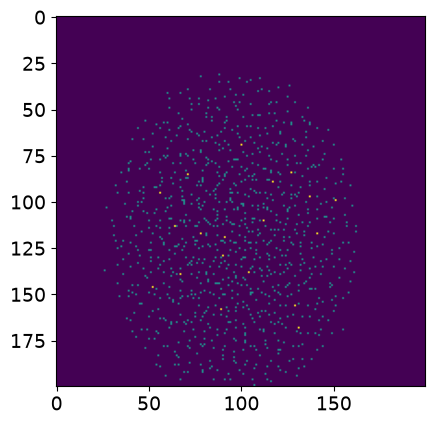

In [5]:
import matplotlib.pyplot as plt
import numpy as np

image_data = model.get(["OTRS:IN20:571:Image:ArrayData"])["OTRS:IN20:571:Image:ArrayData"]
q_nominal = model.get(["QUAD:IN20:525:BCTRL"])["QUAD:IN20:525:BCTRL"]

# scan quad +/- 10%
q_scan = np.linspace(q_nominal * 0.0, q_nominal * 1.1, 5)

for q in q_scan:
    model.set({"QUAD:IN20:525:BCTRL": q})
    image_data = model.get(["OTRS:IN20:571:Image:ArrayData"])["OTRS:IN20:571:Image:ArrayData"]

    plt.figure()
    plt.imshow(np.array(image_data[400:600, 600:800]))

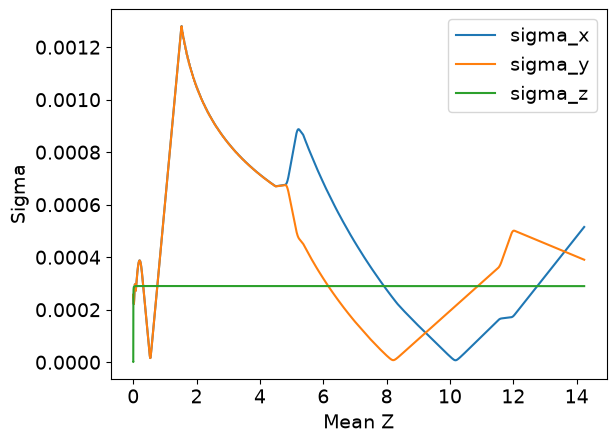

In [6]:
fig, ax = plt.subplots()
ax.plot(model.get(["stat:mean_z"])["stat:mean_z"], model.get(["stat:sigma_x"])["stat:sigma_x"], label="sigma_x")
ax.plot(model.get(["stat:mean_z"])["stat:mean_z"], model.get(["stat:sigma_y"])["stat:sigma_y"], label="sigma_y")
ax.plot(model.get(["stat:mean_z"])["stat:mean_z"], model.get(["stat:sigma_z"])["stat:sigma_z"], label="sigma_z")
ax.set_xlabel("Mean Z")
ax.set_ylabel("Sigma")
ax.legend()

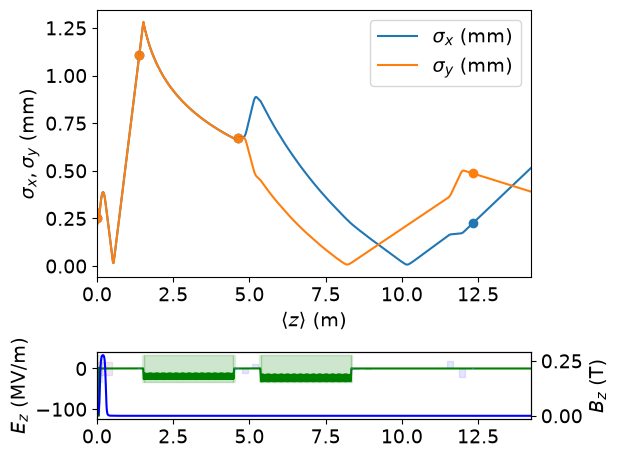

In [7]:
model.impact_model.simulator.plot()

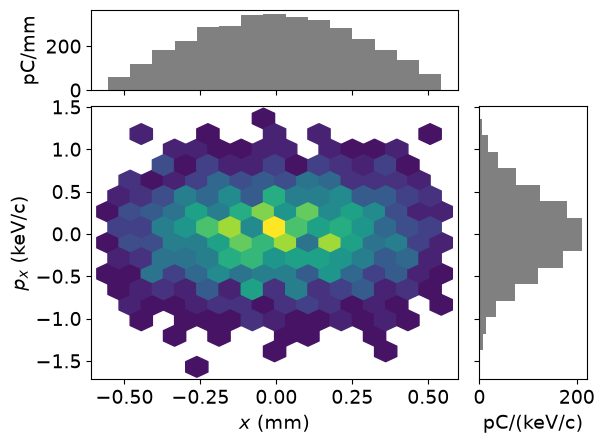

In [8]:
model.distgen_model.simulator.run().plot("x", "px")